In [1]:
import MDAnalysis as mda
from MDAnalysis.analysis import distances, contacts, rms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

import warnings
# suppress some MDAnalysis warnings about writing PDB files
warnings.filterwarnings("ignore")

# the next line is necessary to display plots in Jupyter
%matplotlib inline

In [2]:
mutation = "S321A"
peptide = "MRD"
protein = "WD40"

base_path = f"C:/Users/e216138h/Desktop/Stage/Dossier_Florent/M2/Modelisation/Partenaire/TBL1R/DM/new_MD/mNFIL3_100ns/Distance/Mutations/V3/{mutation}/"
#base_path = f"C:/Users/e216138h/Desktop/Stage/Doc_pc_ubuntu/GLiCID/GROMACS/Results/"

In [3]:
##### Analyse DM pour RMSD, RMSF, Rayon de giration et ACP d'une trajectoire #####

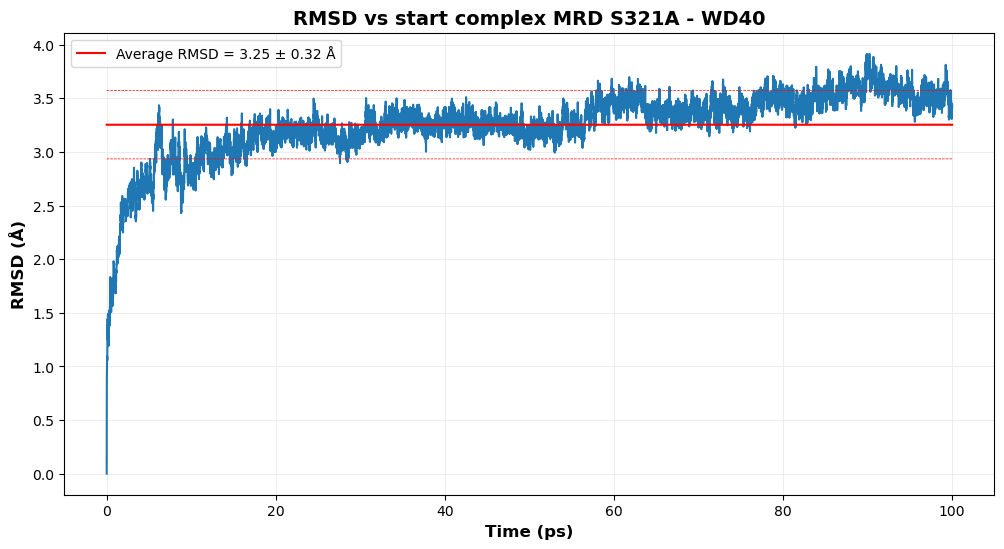

In [4]:
# RMSD vs ref (frame0)

x, y = [], []
with open(base_path+"rmsd_vs_start.xvg") as f:
    for line in f:
        if line.startswith(("@", "#")):
            continue
        cols = line.strip().split()
        x.append(float(cols[0])/1000)
        y.append(float(cols[1])*10)

mean_y = np.mean(y)
std_y = np.std(y)

plt.figure(figsize=(12, 6))
plt.plot(x, y)
plt.plot(x, np.full_like(y, mean_y, dtype=float), linestyle="-", c="red", label=f"Average RMSD = {mean_y:.2f} ± {std_y:.2f} Å")
plt.plot(x, np.full_like(y, (mean_y - std_y), dtype=float), linestyle="--", c="red", linewidth=0.5)
plt.plot(x, np.full_like(y, (mean_y + std_y), dtype=float), linestyle="--", c="red", linewidth=0.5)

plt.title(f"RMSD vs start complex {peptide} {mutation} - {protein}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ps)", fontsize=12, fontweight="bold")
plt.ylabel("RMSD (Å)", fontsize=12, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.legend()
plt.savefig(f"{base_path}rmsd_plot_start_{mutation}.png", dpi=300)
plt.show()

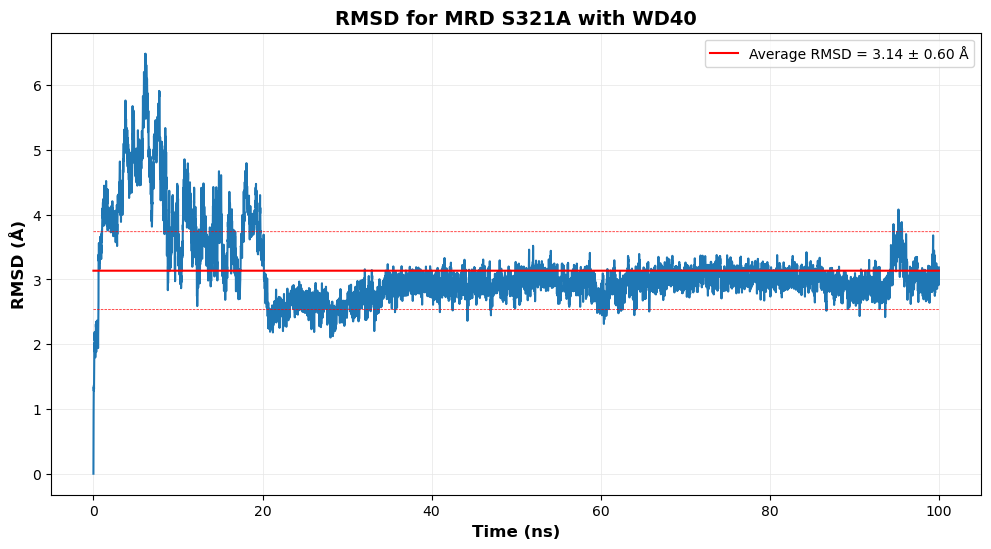

In [5]:
# RMSD MRD vs ref

x, y = [], []
with open(base_path+"rmsd_peptide.xvg") as f:
    for line in f:
        if line.startswith(("@", "#")):
            continue
        cols = line.strip().split()
        x.append(float(cols[0])/1000)
        y.append(float(cols[1])*10)

mean_y = np.mean(y)
std_y = np.std(y)

plt.figure(figsize=(12, 6))
plt.plot(x, y)
plt.plot(x, np.full_like(y, mean_y, dtype=float), linestyle="-", c="red", label=f"Average RMSD = {mean_y:.2f} ± {std_y:.2f} Å")
plt.plot(x, np.full_like(y, (mean_y - std_y), dtype=float), linestyle="--", c="red", linewidth=0.5)
plt.plot(x, np.full_like(y, (mean_y + std_y), dtype=float), linestyle="--", c="red", linewidth=0.5)

plt.title(f"RMSD for {peptide} {mutation} with {protein}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("RMSD (Å)", fontsize=12, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.legend()
plt.savefig(f"{base_path}rmsd_plot_{peptide}_{mutation}.png", dpi=300)
plt.show()

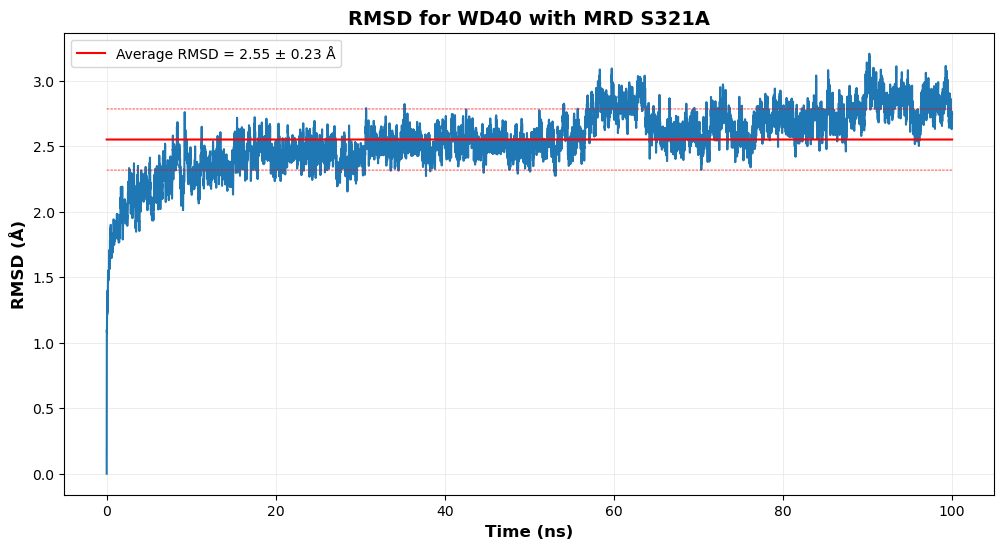

In [6]:
# RMSD WD40 vs ref

x, y = [], []
with open(base_path+"rmsd_protein.xvg") as f:
    for line in f:
        if line.startswith(("@", "#")):
            continue
        cols = line.strip().split()
        x.append(float(cols[0])/1000)
        y.append(float(cols[1])*10)

mean_y = np.mean(y)
std_y = np.std(y)

plt.figure(figsize=(12, 6))
plt.plot(x, y)
plt.plot(x, np.full_like(y, mean_y, dtype=float), linestyle="-", c="red", label=f"Average RMSD = {mean_y:.2f} ± {std_y:.2f} Å")
plt.plot(x, np.full_like(y, (mean_y - std_y), dtype=float), linestyle="--", c="red", linewidth=0.5)
plt.plot(x, np.full_like(y, (mean_y + std_y), dtype=float), linestyle="--", c="red", linewidth=0.5)

plt.title(f"RMSD for {protein} with {peptide} {mutation}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("RMSD (Å)", fontsize=12, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.legend()
plt.savefig(f"{base_path}rmsd_plot_{protein}_{mutation}.png", dpi=300)
plt.show()

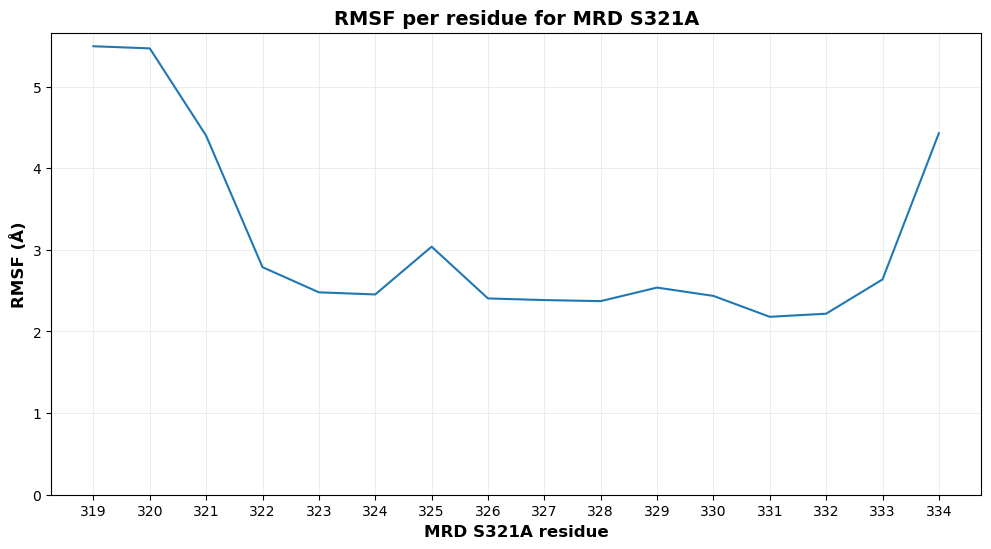

In [7]:
# RMSF par résidus

# MRD
x, y = [], []
with open(base_path+"rmsf_per_residue.xvg") as f:
    i = 0
    for line in f:
        if line.startswith(("@", "#")):
            continue
        i += 1
        if i <= 16:
            cols = line.strip().split()
            x.append(float(cols[0]))
            y.append(float(cols[1])*10)

plt.figure(figsize=(12, 6))
plt.plot(x, y)
plt.title(f"RMSF per residue for {peptide} {mutation}", fontsize=14, fontweight="bold")
plt.xlabel(f"{peptide} {mutation} residue", fontsize=12, fontweight="bold")
plt.ylabel("RMSF (Å)", fontsize=12, fontweight="bold")
plt.ylim(0,)
plt.gca().xaxis.set_major_locator(MultipleLocator(1))
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.savefig(f"{base_path}rmsf_plot_{peptide}_{mutation}.png", dpi=300)
plt.show()

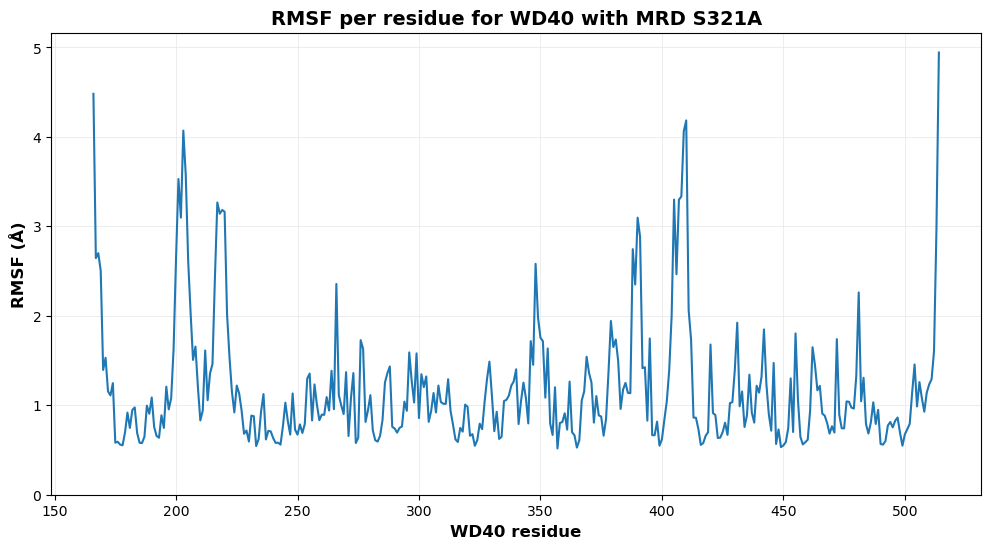

In [8]:
# RMSF par résidus

# WD40
x, y = [], []
with open(base_path+"rmsf_per_residue.xvg") as f:
    i = 0
    for line in f:
        if line.startswith(("@", "#")):
            continue
        i += 1
        if i > 16:
            cols = line.strip().split()
            x.append(float(cols[0]))
            y.append(float(cols[1])*10)

plt.figure(figsize=(12, 6))
plt.plot(x, y)
plt.title(f"RMSF per residue for {protein} with {peptide} {mutation}", fontsize=14, fontweight="bold")
plt.xlabel(f"{protein} residue", fontsize=12, fontweight="bold")
plt.ylabel("RMSF (Å)", fontsize=12, fontweight="bold")
plt.ylim(0,)
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.savefig(f"{base_path}rmsf_plot_{protein}_{mutation}.png", dpi=300)
plt.show()

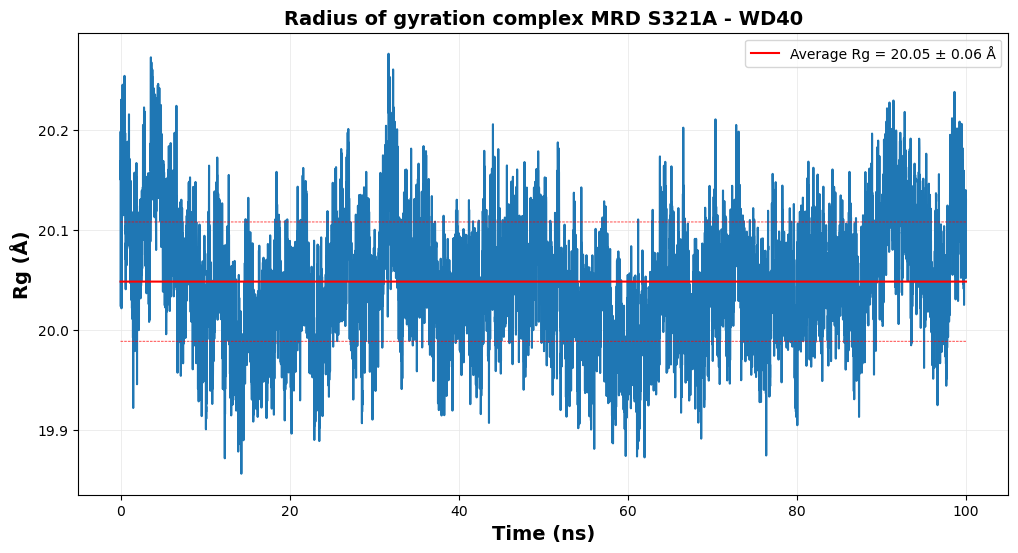

In [9]:
# Rayon de giration

x, y = [], []
with open(base_path+"gyrate.xvg") as f:
    for line in f:
        if line.startswith(("@", "#")):
            continue
        cols = line.strip().split()
        x.append(float(cols[0])/1000)
        y.append(float(cols[1])*10)

mean_y = np.mean(y)
std_y = np.std(y)

plt.figure(figsize=(12, 6))
plt.plot(x, y)
plt.plot(x, np.full_like(y, mean_y, dtype=float), linestyle="-", c="red", label=f"Average Rg = {mean_y:.2f} ± {std_y:.2f} Å")
plt.plot(x, np.full_like(y, (mean_y - std_y), dtype=float), linestyle="--", c="red", linewidth=0.5)
plt.plot(x, np.full_like(y, (mean_y + std_y), dtype=float), linestyle="--", c="red", linewidth=0.5)

plt.title(f"Radius of gyration complex {peptide} {mutation} - {protein}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=14, fontweight="bold")
plt.ylabel("Rg (Å)", fontsize=14, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.legend()
plt.savefig(f"{base_path}gyrate_plot_{mutation}.png", dpi=300)
plt.show()

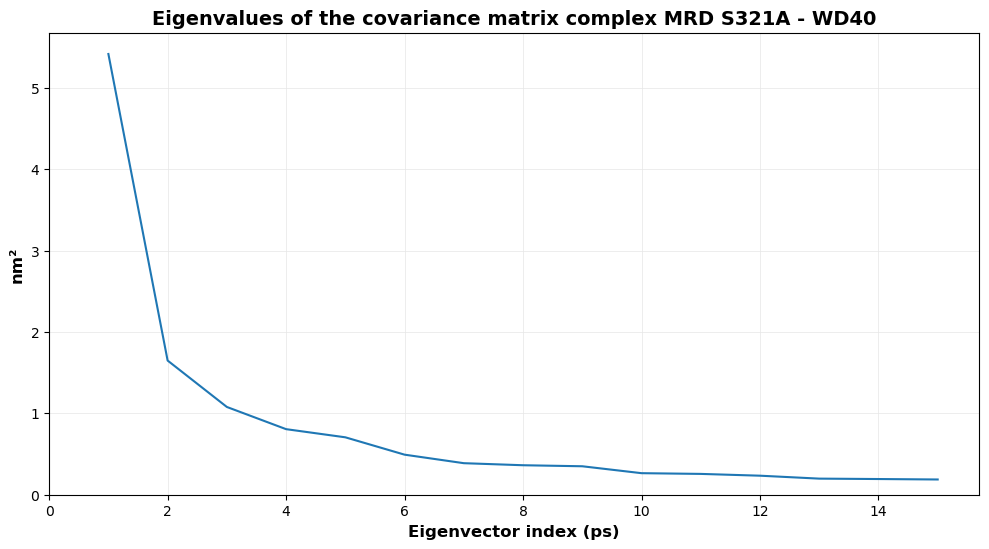

In [10]:
# ACP de la trajectoire

x, y = [], []
with open(base_path+"eigenvalues.xvg") as f:
    i = 0
    for line in f:
        if line.startswith(("@", "#")):
            continue
        i += 1
        if i <= 15:
            cols = line.strip().split()
            x.append(float(cols[0]))
            y.append(float(cols[1]))

plt.figure(figsize=(12, 6))
plt.plot(x, y)
plt.title(f"Eigenvalues of the covariance matrix complex {peptide} {mutation} - {protein}", fontsize=14, fontweight="bold")
plt.xlabel("Eigenvector index (ps)", fontsize=12, fontweight="bold")
plt.ylabel("nm²", fontsize=12, fontweight="bold")
plt.xlim(0,)
plt.ylim(0,)
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.savefig(f"{base_path}eigenvalues_plot_{mutation}.png", dpi=300)
plt.show()

In [11]:
########## Etude des contacts d'un complexe protéique lors d'une simulation de DM ##########

In [12]:
base_path_traj = f"E:/Trajectoire_MD/mNFIL3_100ns/Distance/Mutations/V3/{mutation}/"

GRO = base_path+"md_0_1.gro"
XTC = base_path_traj+"md_0_1_noPBC.xtc"

In [15]:
u_gro = mda.Universe(GRO, XTC)

In [16]:
# Fonction qui trouve le nombre d'atomes dans le peptide associé au WD40

def find_atoms_numbers(gro_file):
    
    with open(gro_file, "r") as f:
        lines = f.readlines()
    
    atom_lines = lines[2:-1]
    atoms = 0
    
    for line in atom_lines:
        atoms += 1
        if line.startswith("  166ARG      N"):
            return(int(atoms-1))

In [17]:
# ATTENTION: le compte des atomes commencent à 0 pour les fichiers .gro et à 1 pour les fichiers .pdb!
# Changer la variable "peptide_count" fonction du complexe (mutation...) => 1er ligne du fichier "output_analyse.out"

peptide_count = find_atoms_numbers(base_path+"md_0_1.gro")
print(peptide_count)

protein_begin = peptide_count
protein_end = protein_begin + 5251 # ne fonctionne que pour le domaine WD40 de TBL1R

MRD = u_gro.atoms[0:peptide_count]
print(MRD)
WD40 = u_gro.atoms[protein_begin:protein_end]
print(WD40)

266
<AtomGroup [<Atom 1: N of type N of resname ASN, resid 319 and segid SYSTEM>, <Atom 2: H1 of type H of resname ASN, resid 319 and segid SYSTEM>, <Atom 3: H2 of type H of resname ASN, resid 319 and segid SYSTEM>, ..., <Atom 264: C of type C of resname MET, resid 334 and segid SYSTEM>, <Atom 265: O1 of type O of resname MET, resid 334 and segid SYSTEM>, <Atom 266: O2 of type O of resname MET, resid 334 and segid SYSTEM>]>
<AtomGroup [<Atom 267: N of type N of resname ARG, resid 166 and segid SYSTEM>, <Atom 268: H1 of type H of resname ARG, resid 166 and segid SYSTEM>, <Atom 269: H2 of type H of resname ARG, resid 166 and segid SYSTEM>, ..., <Atom 5515: C of type C of resname LYS, resid 514 and segid SYSTEM>, <Atom 5516: O1 of type O of resname LYS, resid 514 and segid SYSTEM>, <Atom 5517: O2 of type O of resname LYS, resid 514 and segid SYSTEM>]>


In [18]:
# Définition des pseudo ponts-salins comme contacts

sel_basic = "(resname ARG LYS HIS) and (name NH* NZ ND1 NE* HH1* HH2* HE HE2 HZ*)"
sel_acidic = "name OE* OD*"

basic = MRD.select_atoms(sel_basic)
print(basic, len(basic))
acidic = WD40.select_atoms(sel_acidic)
print(acidic, len(acidic))

<AtomGroup [<Atom 92: ND1 of type N of resname HIS, resid 325 and segid SYSTEM>, <Atom 97: NE2 of type N of resname HIS, resid 325 and segid SYSTEM>, <Atom 98: HE2 of type H of resname HIS, resid 325 and segid SYSTEM>, ..., <Atom 234: HZ1 of type H of resname LYS, resid 332 and segid SYSTEM>, <Atom 235: HZ2 of type H of resname LYS, resid 332 and segid SYSTEM>, <Atom 236: HZ3 of type H of resname LYS, resid 332 and segid SYSTEM>]> 26
<AtomGroup [<Atom 329: OE1 of type O of resname GLU, resid 169 and segid SYSTEM>, <Atom 330: OE2 of type O of resname GLU, resid 169 and segid SYSTEM>, <Atom 355: OE1 of type O of resname GLU, resid 171 and segid SYSTEM>, ..., <Atom 5357: OD2 of type O of resname ASP, resid 504 and segid SYSTEM>, <Atom 5448: OD1 of type O of resname ASP, resid 511 and segid SYSTEM>, <Atom 5449: OD2 of type O of resname ASP, resid 511 and segid SYSTEM>]> 105


In [19]:
### Analyse du nombre de contacts ###

In [20]:
# Fonction qui calcule le nombre de contacts entre 2 groupes et dans le rayon définis pour chaque frame de la trajectoire

def contacts_within_cutoff(u, group_a, group_b, radius=4.5):
    timeseries = []
    for ts in u.trajectory:
        # calculate distances between group_a and group_b
        dist = contacts.distance_array(group_a.positions, group_b.positions)
        # determine which distances <= radius
        n_contacts = contacts.contact_matrix(dist, radius).sum()
        timeseries.append([ts.frame, ts.frame/100, n_contacts])
    return np.array(timeseries)

In [21]:
ca = contacts_within_cutoff(u_gro, acidic, basic, radius=4.5)
ca.shape

(10001, 3)

In [22]:
ca_df = pd.DataFrame(ca, columns=["Frame", "Time (ns)", "# Contacts"])
print(ca_df.head(),"\n", ca_df.tail())

   Frame  Time (ns)  # Contacts
0    0.0       0.00         1.0
1    1.0       0.01         5.0
2    2.0       0.02         5.0
3    3.0       0.03         3.0
4    4.0       0.04         8.0 
          Frame  Time (ns)  # Contacts
9996    9996.0      99.96        20.0
9997    9997.0      99.97        26.0
9998    9998.0      99.98        27.0
9999    9999.0      99.99        27.0
10000  10000.0     100.00        24.0


In [23]:
compte_all = ca_df["# Contacts"].value_counts().sort_index()
#print(compte_all)

moyenne_all = ca_df["# Contacts"].mean()
print(moyenne_all)

median_all = ca_df["# Contacts"].median()
print(median_all)

std_all = ca_df["# Contacts"].std()
print(std_all)

25.051294870512947
25.0
5.968087513864277


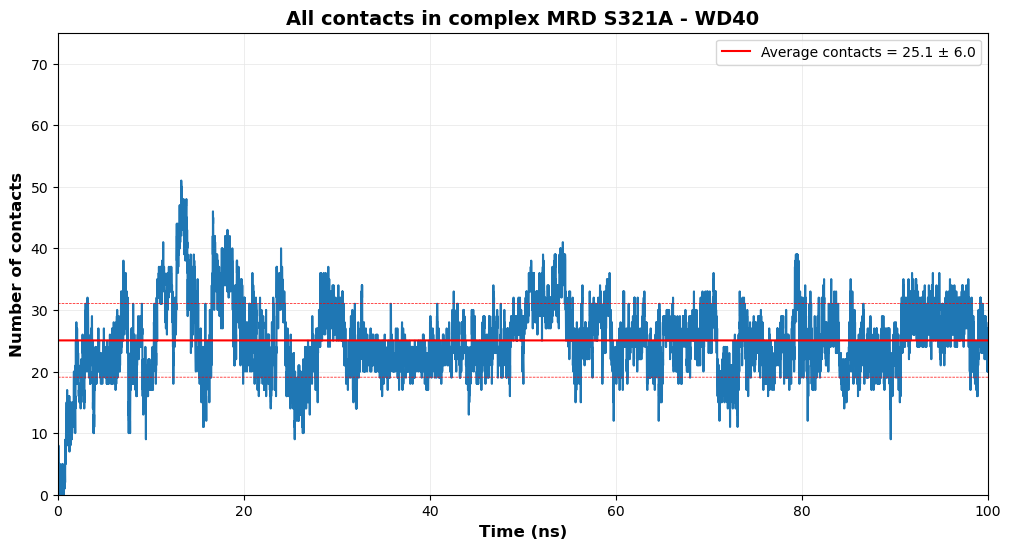

In [24]:
# Graph

plt.figure(figsize=(12, 6))
plt.plot(ca_df["Time (ns)"], ca_df["# Contacts"])
plt.plot(ca_df["Time (ns)"], np.full_like(ca_df["Time (ns)"], moyenne_all, dtype=float), linestyle="-", c="red", label=f"Average contacts = {moyenne_all:.1f} ± {std_all:.1f}")
plt.plot(ca_df["Time (ns)"], np.full_like(ca_df["Time (ns)"], (moyenne_all - std_all), dtype=float), linestyle="--", c="red", linewidth=0.5)
plt.plot(ca_df["Time (ns)"], np.full_like(ca_df["Time (ns)"], (moyenne_all + std_all), dtype=float), linestyle="--", c="red", linewidth=0.5)

plt.title(f"All contacts in complex {peptide} {mutation} - {protein}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("Number of contacts", fontsize=12, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.xlim(0, 100)
plt.ylim(0, 75)
plt.legend()
plt.savefig(f"{base_path}all_contacts_plot_{mutation}.png", dpi=300)
plt.show()

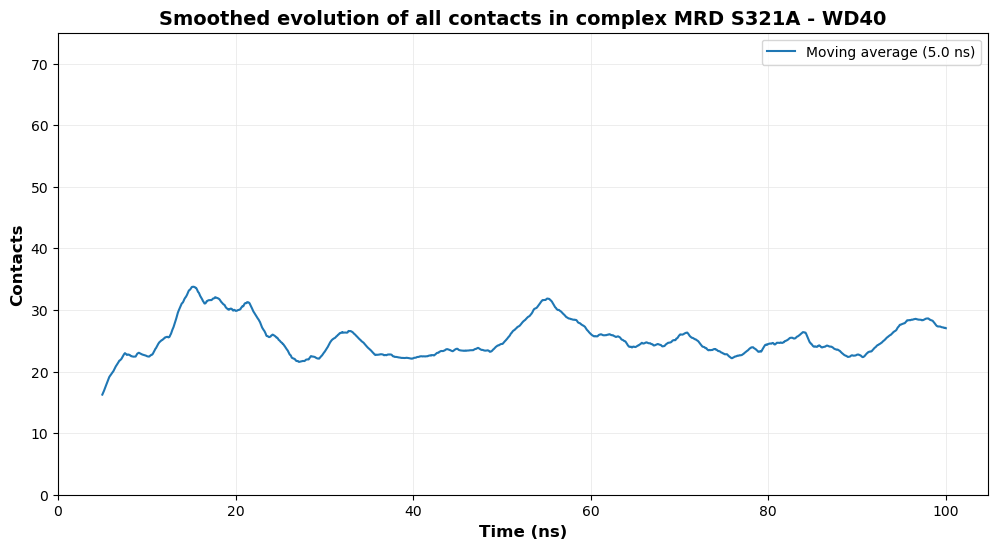

In [25]:
# Graph en "moyenne glissante" pour réduire le bruit de fond

windows = 500
ca_df["Contacts_smooth"] = ca_df["# Contacts"].rolling(window=windows).mean()

plt.figure(figsize=(12, 6))
plt.plot(ca_df["Time (ns)"], ca_df["Contacts_smooth"], label=f"Moving average ({windows/100} ns)")
plt.title(f"Smoothed evolution of all contacts in complex {peptide} {mutation} - {protein}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("Contacts", fontsize=12, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.xlim(0,)
plt.ylim(0, 75)
plt.legend()
plt.savefig(f"{base_path}all_contacts_smoothed_plot_{mutation}.png", dpi=300)
plt.show()

In [26]:
######################### Contacts à partir de résidus spécifiques du MRD #########################

In [27]:
# Sélection des résidus:

sel_H325 = "(resid 325 and name ND1 NE2 HE2)"
sel_R328 = "(resid 328 and name NE NH* HE HH1* HH2*)"
sel_K326 = "(resid 326 and name NZ HZ*)"
sel_K330 = "(resid 330 and name NZ HZ*)"
sel_K332 = "(resid 332 and name NZ HZ*)"

H325 = MRD.select_atoms(sel_H325)
R328 = MRD.select_atoms(sel_R328)
K326 = MRD.select_atoms(sel_K326)
K330 = MRD.select_atoms(sel_K330)
K332 = MRD.select_atoms(sel_K332)

all_basic = H325 + R328 + K326 + K330 + K332

print(H325, R328, K326, K330, K332)
print(len(H325), len(R328), len(K326), len(K330), len(K332))
print(all_basic, len(all_basic))

<AtomGroup [<Atom 92: ND1 of type N of resname HIS, resid 325 and segid SYSTEM>, <Atom 97: NE2 of type N of resname HIS, resid 325 and segid SYSTEM>, <Atom 98: HE2 of type H of resname HIS, resid 325 and segid SYSTEM>]> <AtomGroup [<Atom 155: NE of type N of resname ARG, resid 328 and segid SYSTEM>, <Atom 156: HE of type H of resname ARG, resid 328 and segid SYSTEM>, <Atom 158: NH1 of type N of resname ARG, resid 328 and segid SYSTEM>, <Atom 159: HH11 of type H of resname ARG, resid 328 and segid SYSTEM>, <Atom 160: HH12 of type H of resname ARG, resid 328 and segid SYSTEM>, <Atom 161: NH2 of type N of resname ARG, resid 328 and segid SYSTEM>, <Atom 162: HH21 of type H of resname ARG, resid 328 and segid SYSTEM>, <Atom 163: HH22 of type H of resname ARG, resid 328 and segid SYSTEM>]> <AtomGroup [<Atom 117: NZ of type N of resname LYS, resid 326 and segid SYSTEM>, <Atom 118: HZ1 of type H of resname LYS, resid 326 and segid SYSTEM>, <Atom 119: HZ2 of type H of resname LYS, resid 326 and

In [28]:
# Pour H325

In [29]:
ca_H325_co = contacts_within_cutoff(u_gro, H325, acidic, radius=4.5)

In [30]:
ca_H325_co_df = pd.DataFrame(ca_H325_co, columns=["Frame", "Time (ns)", "# Contacts"])
print(ca_H325_co_df.head(),"\n", ca_H325_co_df.tail())

   Frame  Time (ns)  # Contacts
0    0.0       0.00         0.0
1    1.0       0.01         0.0
2    2.0       0.02         0.0
3    3.0       0.03         0.0
4    4.0       0.04         0.0 
          Frame  Time (ns)  # Contacts
9996    9996.0      99.96         0.0
9997    9997.0      99.97         0.0
9998    9998.0      99.98         0.0
9999    9999.0      99.99         0.0
10000  10000.0     100.00         0.0


In [31]:
compte_H325 = ca_H325_co_df["# Contacts"].value_counts().sort_index()
#print(compte_H325)

moyenne_H325 = ca_H325_co_df["# Contacts"].mean()
print(moyenne_H325)

median_H325 = ca_H325_co_df["# Contacts"].median()
print(median_H325)

std_H325 = ca_H325_co_df["# Contacts"].std()
print(std_H325)

0.20977902209779023
0.0
0.6717055613614372


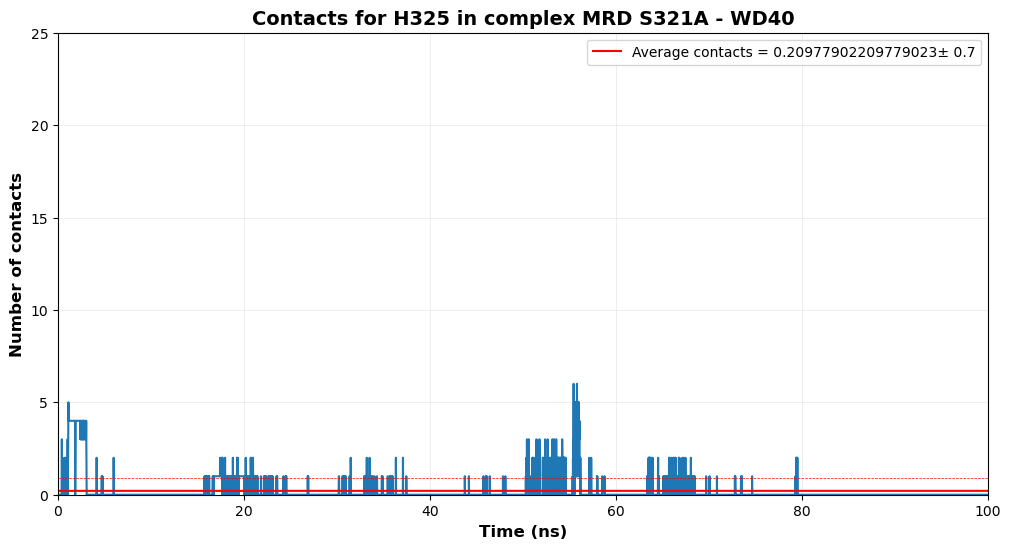

In [32]:
# Graph

plt.figure(figsize=(12, 6))
plt.plot(ca_H325_co_df["Time (ns)"], ca_H325_co_df["# Contacts"])
plt.plot(ca_H325_co_df["Time (ns)"], np.full_like(ca_H325_co_df["Time (ns)"], moyenne_H325, dtype=float), linestyle="-", label=f"Average contacts = {moyenne_H325}± {std_H325:.1f}", c="red")
plt.plot(ca_H325_co_df["Time (ns)"], np.full_like(ca_H325_co_df["Time (ns)"], (moyenne_H325 - std_H325), dtype=float), linestyle="--", c="red", linewidth=0.5)
plt.plot(ca_H325_co_df["Time (ns)"], np.full_like(ca_H325_co_df["Time (ns)"], (moyenne_H325 + std_H325), dtype=float), linestyle="--", c="red", linewidth=0.5)

plt.title(f"Contacts for H325 in complex {peptide} {mutation} - {protein}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("Number of contacts", fontsize=12, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.xlim(0, 100)
plt.ylim(0, 25)
plt.legend()
plt.savefig(f"{base_path}H325_contacts_number_plot_{mutation}.png", dpi=300)
plt.show()

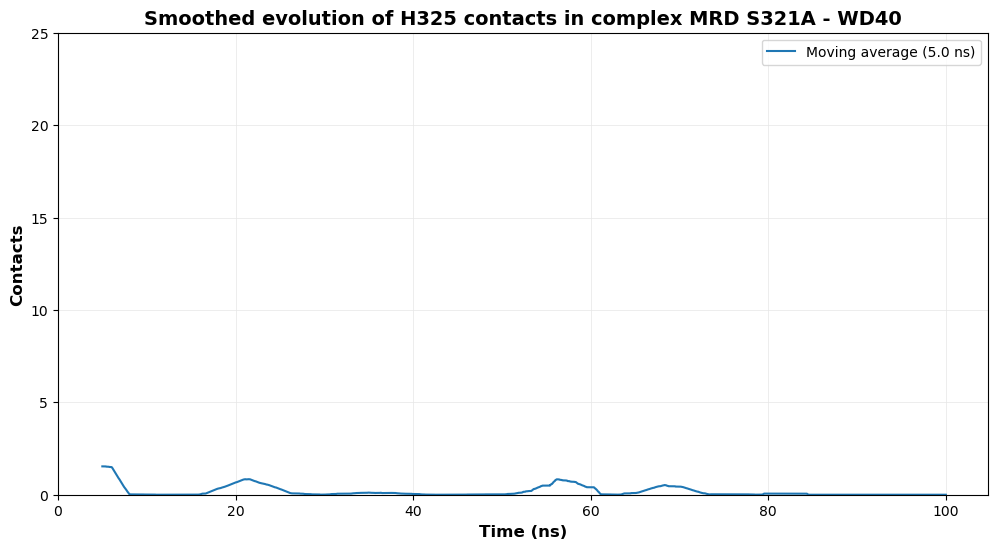

In [33]:
# Graph en "moyenne glissante" pour réduire le bruit de fond

ca_H325_co_df["Contacts_smooth"] = ca_H325_co_df["# Contacts"].rolling(window=windows).mean()

plt.figure(figsize=(12, 6))
plt.plot(ca_H325_co_df["Time (ns)"], ca_H325_co_df["Contacts_smooth"], label=f"Moving average ({windows/100} ns)")
plt.title(f"Smoothed evolution of H325 contacts in complex {peptide} {mutation} - {protein}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("Contacts", fontsize=12, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.xlim(0,)
plt.ylim(0, 25)
plt.legend()
plt.savefig(f"{base_path}H325_contacts_smoothed_plot_{mutation}.png", dpi=300)
plt.show()

In [34]:
# Pour R328

In [35]:
ca_R328_co = contacts_within_cutoff(u_gro, R328, acidic, radius=4.5)

In [36]:
ca_R328_co_df = pd.DataFrame(ca_R328_co, columns=["Frame", "Time (ns)", "# Contacts"])
print(ca_R328_co_df.head(),"\n", ca_R328_co_df.tail())

   Frame  Time (ns)  # Contacts
0    0.0       0.00         0.0
1    1.0       0.01         0.0
2    2.0       0.02         0.0
3    3.0       0.03         0.0
4    4.0       0.04         0.0 
          Frame  Time (ns)  # Contacts
9996    9996.0      99.96         6.0
9997    9997.0      99.97         8.0
9998    9998.0      99.98         8.0
9999    9999.0      99.99         8.0
10000  10000.0     100.00         6.0


In [37]:
compte_R328 = ca_R328_co_df["# Contacts"].value_counts().sort_index()
#print(compte_R328)

moyenne_R328 = ca_R328_co_df["# Contacts"].mean()
print(moyenne_R328)

median_R328 = ca_R328_co_df["# Contacts"].median()
print(median_R328)

std_R328 = ca_R328_co_df["# Contacts"].std()
print(std_R328)

4.1727827217278275
3.0
3.5190827136748903


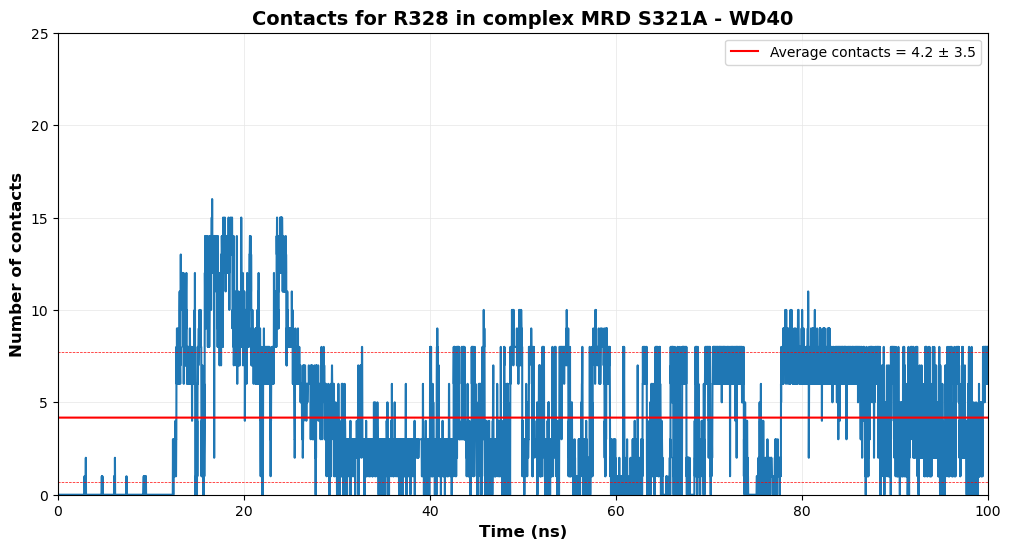

In [38]:
# Graph

plt.figure(figsize=(12, 6))
plt.plot(ca_R328_co_df["Time (ns)"], ca_R328_co_df["# Contacts"])
plt.plot(ca_R328_co_df["Time (ns)"], np.full_like(ca_R328_co_df["Time (ns)"], moyenne_R328, dtype=float), linestyle="-", label=f"Average contacts = {moyenne_R328:.1f} ± {std_R328:.1f}", c="red")
plt.plot(ca_R328_co_df["Time (ns)"], np.full_like(ca_R328_co_df["Time (ns)"], (moyenne_R328 - std_R328), dtype=float), linestyle="--", c="red", linewidth=0.5)
plt.plot(ca_R328_co_df["Time (ns)"], np.full_like(ca_R328_co_df["Time (ns)"], (moyenne_R328 + std_R328), dtype=float), linestyle="--", c="red", linewidth=0.5)

plt.title(f"Contacts for R328 in complex {peptide} {mutation} - {protein}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("Number of contacts", fontsize=12, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.xlim(0, 100)
plt.ylim(0, 25)
plt.legend()
plt.savefig(f"{base_path}R328_contacts_number_plot_{mutation}.png", dpi=300)
plt.show()

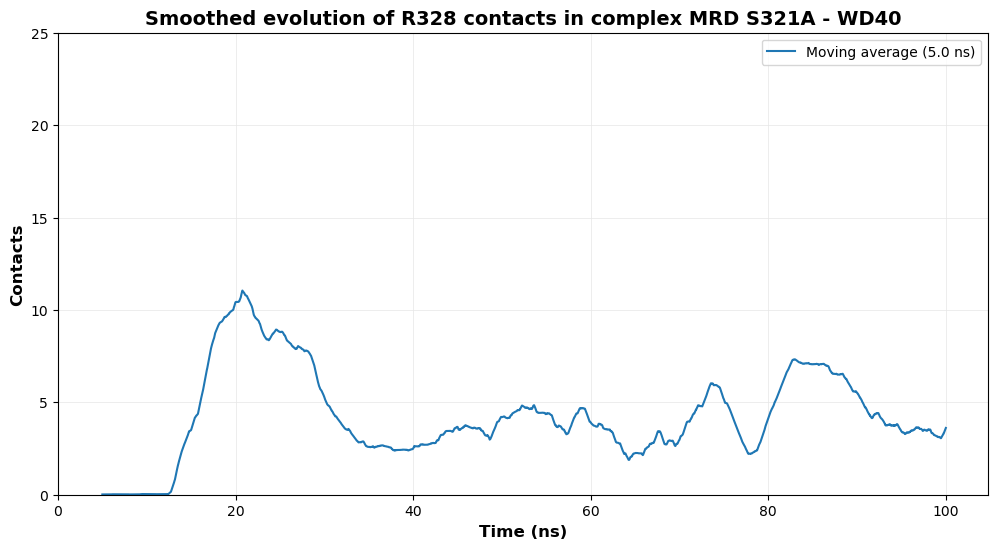

In [39]:
# Graph en "moyenne glissante" pour réduire le bruit de fond

ca_R328_co_df["Contacts_smooth"] = ca_R328_co_df["# Contacts"].rolling(window=windows).mean()

plt.figure(figsize=(12, 6))
plt.plot(ca_R328_co_df["Time (ns)"], ca_R328_co_df["Contacts_smooth"], label=f"Moving average ({windows/100} ns)")
plt.title(f"Smoothed evolution of R328 contacts in complex {peptide} {mutation} - {protein}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("Contacts", fontsize=12, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.xlim(0,)
plt.ylim(0, 25)
plt.legend()
plt.savefig(f"{base_path}R328_contacts_smoothed_plot_{mutation}.png", dpi=300)
plt.show()

In [40]:
# Pour K326

In [41]:
ca_K326_co = contacts_within_cutoff(u_gro, K326, acidic, radius=4.5)

In [42]:
ca_K326_co_df = pd.DataFrame(ca_K326_co, columns=["Frame", "Time (ns)", "# Contacts"])
print(ca_K326_co_df.head(),"\n", ca_K326_co_df.tail())

   Frame  Time (ns)  # Contacts
0    0.0       0.00         1.0
1    1.0       0.01         5.0
2    2.0       0.02         4.0
3    3.0       0.03         2.0
4    4.0       0.04         7.0 
          Frame  Time (ns)  # Contacts
9996    9996.0      99.96         4.0
9997    9997.0      99.97         8.0
9998    9998.0      99.98         8.0
9999    9999.0      99.99         8.0
10000  10000.0     100.00         8.0


In [43]:
compte_K326 = ca_K326_co_df["# Contacts"].value_counts().sort_index()
#print(compte_K326)

moyenne_K326 = ca_K326_co_df["# Contacts"].mean()
print(moyenne_K326)

median_K326 = ca_K326_co_df["# Contacts"].median()
print(median_K326)

std_K326 = ca_K326_co_df["# Contacts"].std()
print(std_K326)

8.29117088291171
8.0
3.9565402865250987


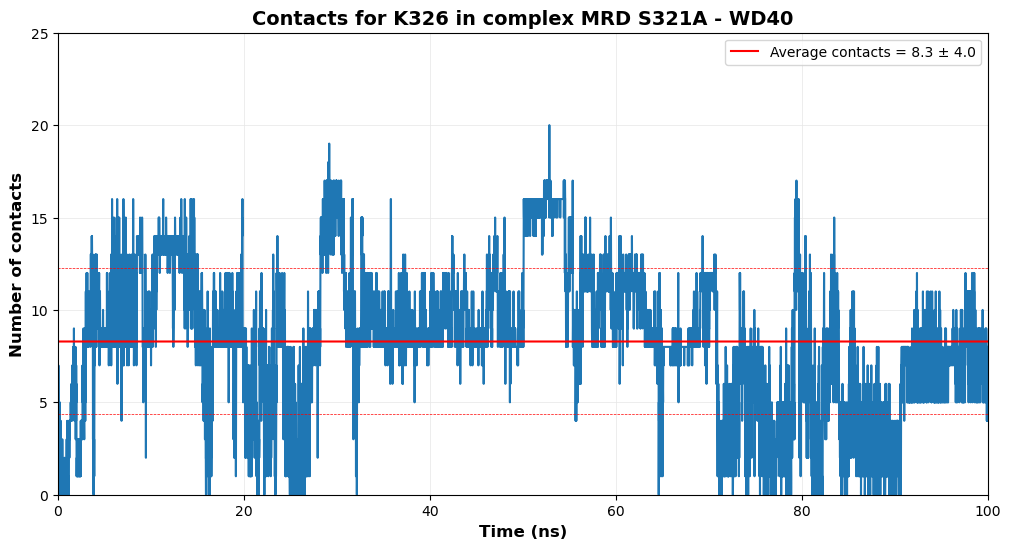

In [44]:
# Graph

plt.figure(figsize=(12, 6))
plt.plot(ca_K326_co_df["Time (ns)"], ca_K326_co_df["# Contacts"])
plt.plot(ca_K326_co_df["Time (ns)"], np.full_like(ca_K326_co_df["Time (ns)"], moyenne_K326, dtype=float), linestyle="-", label=f"Average contacts = {moyenne_K326:.1f} ± {std_K326:.1f}", c="red")
plt.plot(ca_K326_co_df["Time (ns)"], np.full_like(ca_K326_co_df["Time (ns)"], (moyenne_K326 - std_K326), dtype=float), linestyle="--", c="red", linewidth=0.5)
plt.plot(ca_K326_co_df["Time (ns)"], np.full_like(ca_K326_co_df["Time (ns)"], (moyenne_K326 + std_K326), dtype=float), linestyle="--", c="red", linewidth=0.5)

plt.title(f"Contacts for K326 in complex {peptide} {mutation} - {protein}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("Number of contacts", fontsize=12, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.xlim(0, 100)
plt.ylim(0, 25)
plt.legend()
plt.savefig(f"{base_path}K326_contacts_number_plot_{mutation}.png", dpi=300)
plt.show()

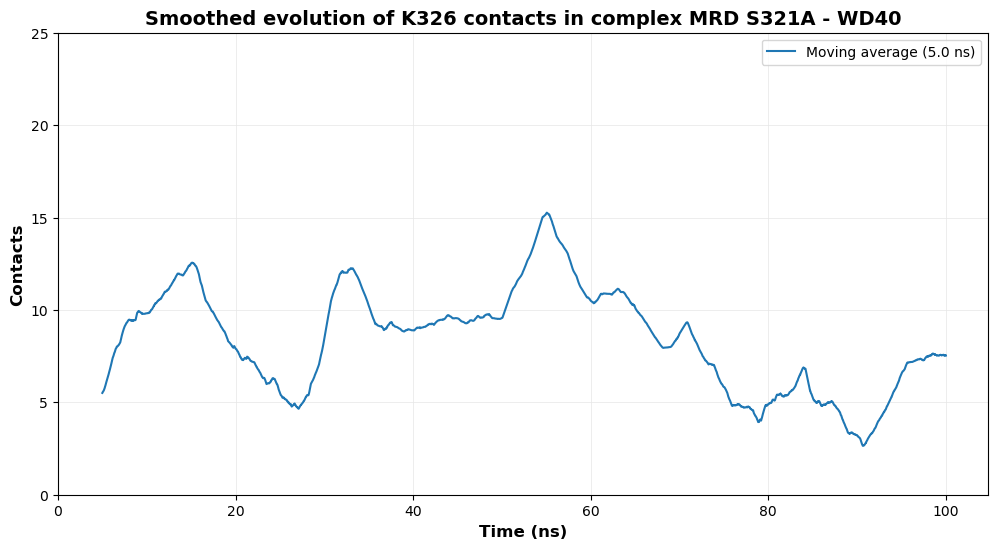

In [45]:
# Graph en "moyenne glissante" pour réduire le bruit de fond

ca_K326_co_df["Contacts_smooth"] = ca_K326_co_df["# Contacts"].rolling(window=windows).mean()

plt.figure(figsize=(12, 6))
plt.plot(ca_K326_co_df["Time (ns)"], ca_K326_co_df["Contacts_smooth"], label=f"Moving average ({windows/100} ns)")
plt.title(f"Smoothed evolution of K326 contacts in complex {peptide} {mutation} - {protein}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("Contacts", fontsize=12, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.xlim(0,)
plt.ylim(0, 25)
plt.legend()
plt.savefig(f"{base_path}K326_contacts_smoothed_plot_{mutation}.png", dpi=300)
plt.show()

In [46]:
# Pour K330

In [47]:
ca_K330_co = contacts_within_cutoff(u_gro, K330, acidic, radius=4.5)

In [48]:
ca_K330_co_df = pd.DataFrame(ca_K330_co, columns=["Frame", "Time (ns)", "# Contacts"])
print(ca_K330_co_df.head(),"\n", ca_K330_co_df.tail())

   Frame  Time (ns)  # Contacts
0    0.0       0.00         0.0
1    1.0       0.01         0.0
2    2.0       0.02         0.0
3    3.0       0.03         0.0
4    4.0       0.04         0.0 
          Frame  Time (ns)  # Contacts
9996    9996.0      99.96         0.0
9997    9997.0      99.97         0.0
9998    9998.0      99.98         0.0
9999    9999.0      99.99         0.0
10000  10000.0     100.00         0.0


In [49]:
compte_K330 = ca_K330_co_df["# Contacts"].value_counts().sort_index()
#print(compte_K330)

moyenne_K330 = ca_K330_co_df["# Contacts"].mean()
print(moyenne_K330)

median_K330 = ca_K330_co_df["# Contacts"].median()
print(median_K330)

std_K330 = ca_K330_co_df["# Contacts"].std()
print(std_K330)

0.96000399960004
0.0
2.2221611462682005


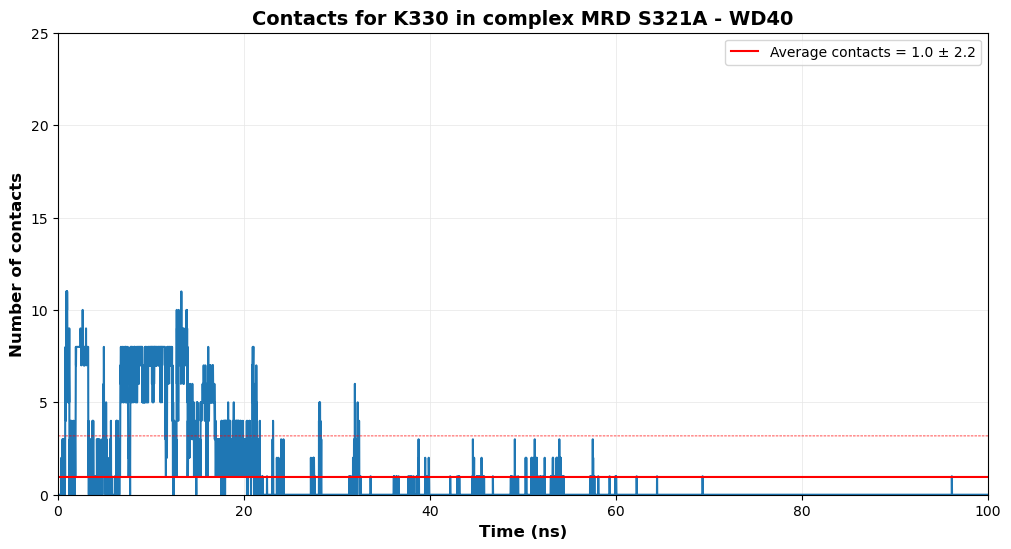

In [50]:
# Graph

plt.figure(figsize=(12, 6))
plt.plot(ca_K330_co_df["Time (ns)"], ca_K330_co_df["# Contacts"])
plt.plot(ca_K330_co_df["Time (ns)"], np.full_like(ca_K330_co_df["Time (ns)"], moyenne_K330, dtype=float), linestyle="-", label=f"Average contacts = {moyenne_K330:.1f} ± {std_K330:.1f}", c="red")
plt.plot(ca_K330_co_df["Time (ns)"], np.full_like(ca_K330_co_df["Time (ns)"], (moyenne_K330 - std_K330), dtype=float), linestyle="--", c="red", linewidth=0.5)
plt.plot(ca_K330_co_df["Time (ns)"], np.full_like(ca_K330_co_df["Time (ns)"], (moyenne_K330 + std_K330), dtype=float), linestyle="--", c="red", linewidth=0.5)

plt.title(f"Contacts for K330 in complex {peptide} {mutation} - {protein}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("Number of contacts", fontsize=12, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.xlim(0, 100)
plt.ylim(0, 25)
plt.legend()
plt.savefig(f"{base_path}K330_contacts_number_plot_{mutation}.png", dpi=300)
plt.show()

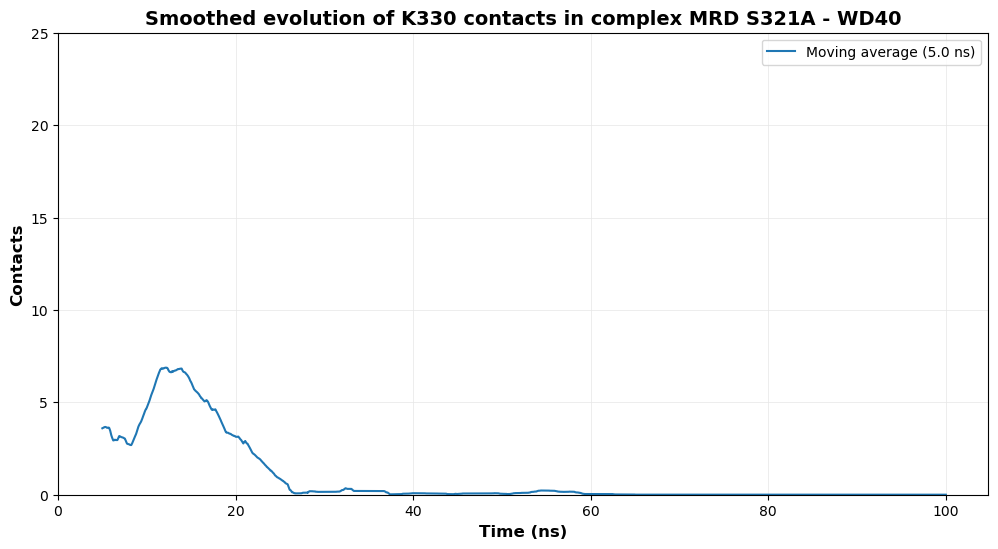

In [51]:
# Graph en "moyenne glissante" pour réduire le bruit de fond

ca_K330_co_df["Contacts_smooth"] = ca_K330_co_df["# Contacts"].rolling(window=windows).mean()

plt.figure(figsize=(12, 6))
plt.plot(ca_K330_co_df["Time (ns)"], ca_K330_co_df["Contacts_smooth"], label=f"Moving average ({windows/100} ns)")
plt.title(f"Smoothed evolution of K330 contacts in complex {peptide} {mutation} - {protein}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("Contacts", fontsize=12, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.xlim(0,)
plt.ylim(0, 25)
plt.legend()
plt.savefig(f"{base_path}K330_contacts_smoothed_plot_{mutation}.png", dpi=300)
plt.show()

In [52]:
# Pour K332

In [53]:
ca_K332_co = contacts_within_cutoff(u_gro, K332, acidic, radius=4.5)

Exception ignored in: <function ReaderBase.__del__ at 0x000001E2960F16C0>
Traceback (most recent call last):
  File "C:\Users\e216138h\anaconda3\envs\analyse_md\Lib\site-packages\MDAnalysis\coordinates\base.py", line 1531, in __del__
    self.close()
  File "C:\Users\e216138h\anaconda3\envs\analyse_md\Lib\site-packages\MDAnalysis\coordinates\XDR.py", line 196, in close
    self._xdr.close()
AttributeError: 'XTCReader' object has no attribute '_xdr'


In [54]:
ca_K332_co_df = pd.DataFrame(ca_K332_co, columns=["Frame", "Time (ns)", "# Contacts"])
print(ca_K332_co_df.head(),"\n", ca_K332_co_df.tail())

   Frame  Time (ns)  # Contacts
0    0.0       0.00         0.0
1    1.0       0.01         0.0
2    2.0       0.02         0.0
3    3.0       0.03         0.0
4    4.0       0.04         0.0 
          Frame  Time (ns)  # Contacts
9996    9996.0      99.96         8.0
9997    9997.0      99.97         8.0
9998    9998.0      99.98         8.0
9999    9999.0      99.99         9.0
10000  10000.0     100.00         8.0


In [55]:
compte_K332 = ca_K332_co_df["# Contacts"].value_counts().sort_index()
#print(compte_K332)

moyenne_K332 = ca_K332_co_df["# Contacts"].mean()
print(moyenne_K332)

median_K332 = ca_K332_co_df["# Contacts"].median()
print(median_K332)

std_K332 = ca_K332_co_df["# Contacts"].std()
print(std_K332)

8.543645635436457
8.0
3.5317304353550543


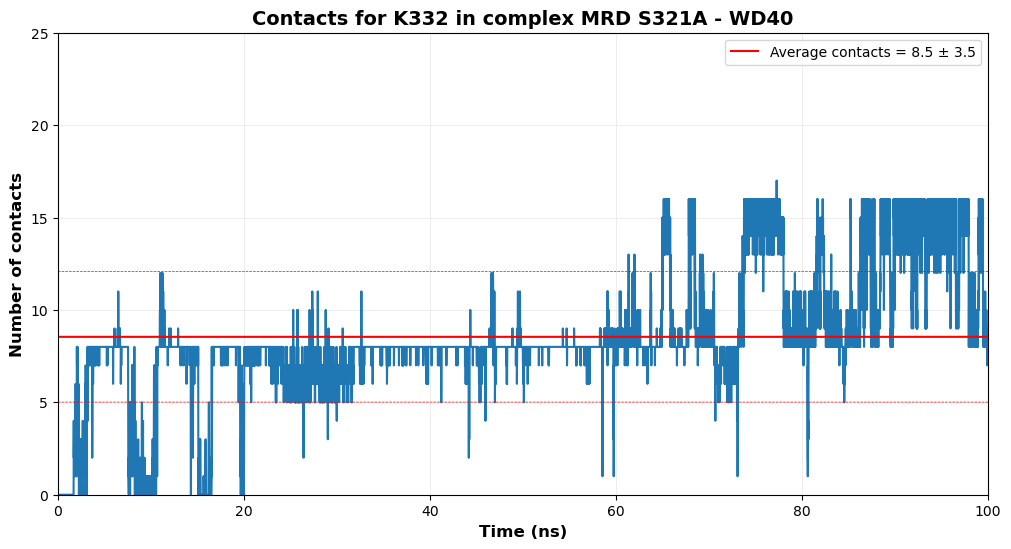

In [56]:
# Graph

plt.figure(figsize=(12, 6))
plt.plot(ca_K332_co_df["Time (ns)"], ca_K332_co_df["# Contacts"])
plt.plot(ca_K332_co_df["Time (ns)"], np.full_like(ca_K332_co_df["Time (ns)"], moyenne_K332, dtype=float), linestyle="-", label=f"Average contacts = {moyenne_K332:.1f} ± {std_K332:.1f}", c="red")
plt.plot(ca_K332_co_df["Time (ns)"], np.full_like(ca_K332_co_df["Time (ns)"], (moyenne_K332 - std_K332), dtype=float), linestyle="--", c="red", linewidth=0.5)
plt.plot(ca_K332_co_df["Time (ns)"], np.full_like(ca_K332_co_df["Time (ns)"], (moyenne_K332 + std_K332), dtype=float), linestyle="--", c="red", linewidth=0.5)

plt.title(f"Contacts for K332 in complex {peptide} {mutation} - {protein}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("Number of contacts", fontsize=12, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.xlim(0, 100)
plt.ylim(0, 25)
plt.legend()
plt.savefig(f"{base_path}K332_contacts_number_plot_{mutation}", dpi=300)
plt.show()

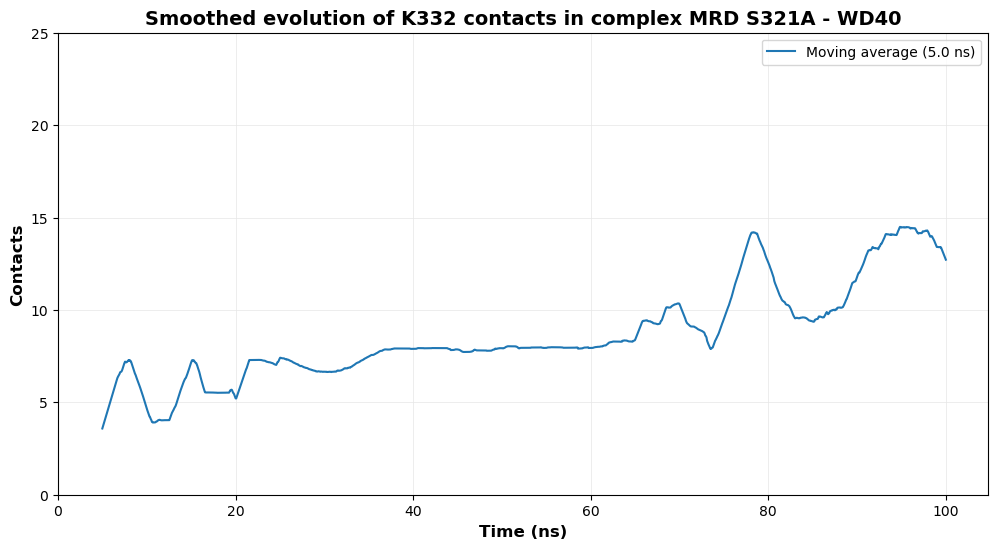

In [57]:
# Graph en "moyenne glissante" pour réduire le bruit de fond

ca_K332_co_df["Contacts_smooth"] = ca_K332_co_df["# Contacts"].rolling(window=windows).mean()

plt.figure(figsize=(12, 6))
plt.plot(ca_K332_co_df["Time (ns)"], ca_K332_co_df["Contacts_smooth"], label=f"Moving average ({windows/100} ns)")
plt.title(f"Smoothed evolution of K332 contacts in complex {peptide} {mutation} - {protein}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("Contacts", fontsize=12, fontweight="bold")
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.xlim(0,)
plt.ylim(0,25)
plt.legend()
plt.savefig(f"{base_path}K332_contacts_smoothed_plot_{mutation}.png", dpi=300)
plt.show()

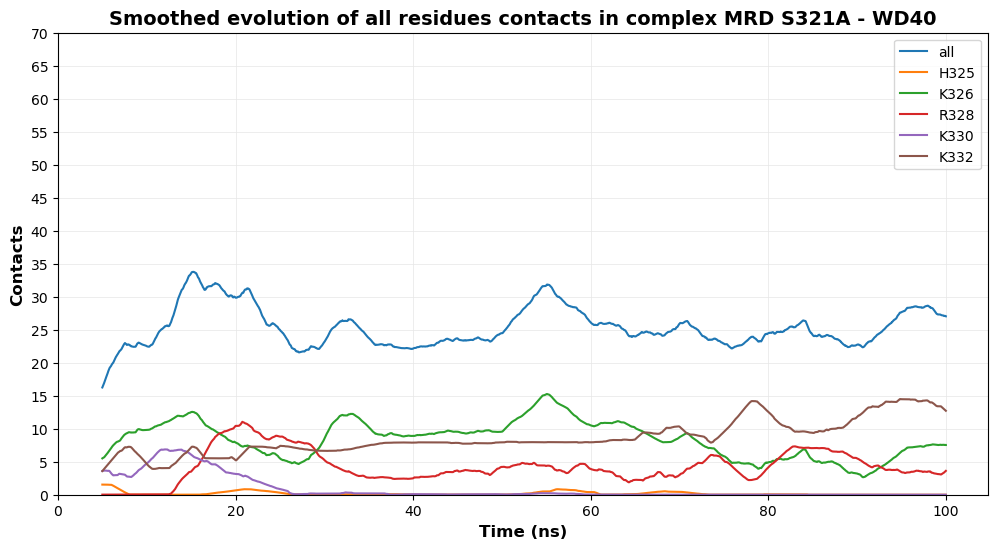

In [58]:
# Graph avec tous les résidus impliqués dans des contacts électrostatiques

plt.figure(figsize=(12, 6))
plt.plot(ca_df["Time (ns)"], ca_df["Contacts_smooth"], label="all")
plt.plot(ca_df["Time (ns)"], ca_H325_co_df["Contacts_smooth"], label="H325")
plt.plot(ca_df["Time (ns)"], ca_K326_co_df["Contacts_smooth"], label="K326")
plt.plot(ca_df["Time (ns)"], ca_R328_co_df["Contacts_smooth"], label="R328")
plt.plot(ca_df["Time (ns)"], ca_K330_co_df["Contacts_smooth"], label="K330")
plt.plot(ca_df["Time (ns)"], ca_K332_co_df["Contacts_smooth"], label="K332")

plt.title(f"Smoothed evolution of all residues contacts in complex {peptide} {mutation} - {protein}", fontsize=14, fontweight="bold")
plt.xlabel("Time (ns)", fontsize=12, fontweight="bold")
plt.ylabel("Contacts", fontsize=12, fontweight="bold")
plt.xlim(0,)
plt.ylim(0, 70)

plt.gca().yaxis.set_major_locator(MultipleLocator(5))
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.legend()
plt.savefig(f"{base_path}all_residues_contacts_smoothed_plot_{mutation}.png", dpi=300)
plt.show()

In [59]:
########## Calcul et plot de l'énergie de liaisons Peptide-Proteine au cours du temps ##########

In [60]:
"""
Calculate MM binding energy (Electrostatic + VdW) in kJ/mol
Uses simplified Coulomb and Lennard-Jones potentials
"""

print("Calculating MM Binding Energy...")

energies = []
time_ns = []

# Constants
epsilon_0 = 8.854187817e-12  # Vacuum permittivity (F/m)
epsilon_r = 1.0  # Relative permittivity (vacuum approximation)
e = 1.602176634e-19  # Elementary charge (C)
Na = 6.02214076e23  # Avogadro's number

# Coulomb constant in kJ/(mol·nm)
# k_e = (1 / (4π * ε₀ * ε_r)) * e² * Na / 1000
k_e = 138.935458  # kJ·nm/(mol·e²) - standard value for MD simulations

# Lennard-Jones parameters (typical protein-ligand values)
epsilon_lj = 0.5  # kJ/mol - depth of potential well
sigma = 0.35  # nm - distance at which potential is zero

for ts in u_gro.trajectory:
    # Get protein-ligand distance matrix in Angstroms
    distances_angstrom = mda.lib.distances.distance_array(MRD.positions, WD40.positions)

    # Convert to nm for proper energy calculation
    distances_nm = distances_angstrom / 10.0

    # Avoid division by zero
    distances_nm = np.maximum(distances_nm, 0.01)  # Minimum distance 0.01 nm

    # Electrostatic energy (Coulomb's law)
    # E_elec = k_e * q1 * q2 / r
    # Assuming partial charges of ±0.5e for simplified calculation
    q_protein = 0.5  # Partial charge (elementary charge units)
    q_ligand = 0.5
    elec_energy = k_e * q_protein * q_ligand / distances_nm
    total_elec = np.sum(elec_energy)

    # Van der Waals energy (Lennard-Jones 6-12 potential)
    # E_vdw = 4ε[(σ/r)^12 - (σ/r)^6]
    sigma_r = sigma / distances_nm
    vdw_energy = 4 * epsilon_lj * (sigma_r**12 - sigma_r**6)
    total_vdw = np.sum(vdw_energy)

    # Total interaction energy
    total_energy = total_elec + total_vdw

    energies.append(total_energy)
    time_ns.append(ts.time / 1000.0)

print("Calcul MM Binding Energy done!")

Calculating MM Binding Energy...
Calcul MM Binding Energy done!


Binding energy plot saved to C:/Users/e216138h/Desktop/Stage/Dossier_Florent/M2/Modelisation/Partenaire/TBL1R/DM/new_MD/mNFIL3_100ns/Distance/Mutations/V3/S321A/energy.png
Mean Energy: 20576934.82 ± 941330.77 kJ/mol


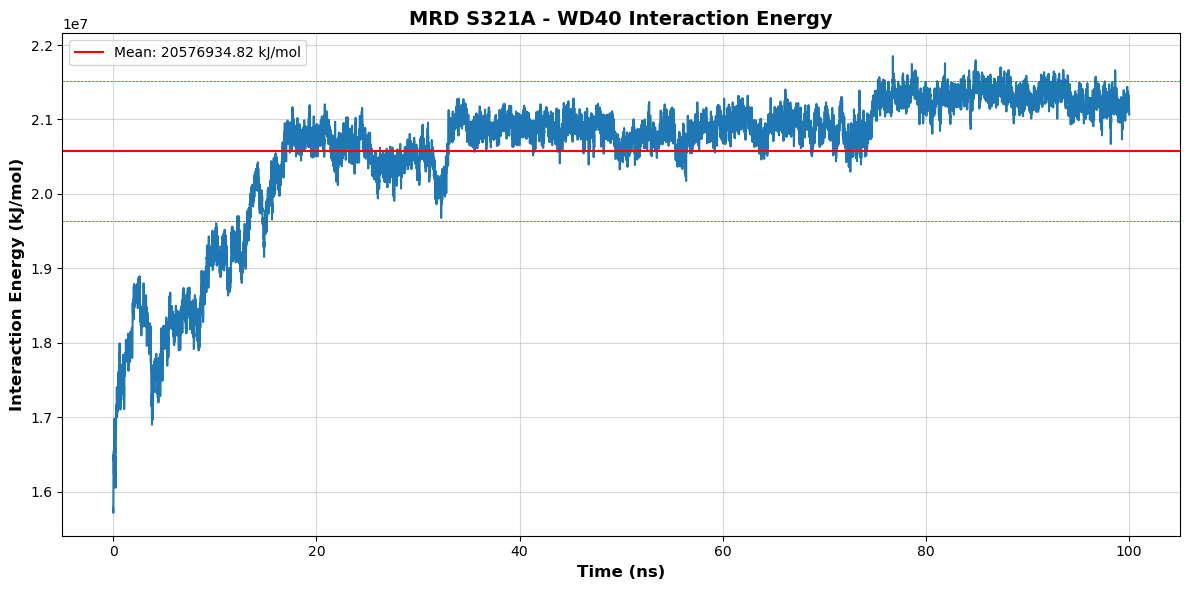

In [61]:
"""
Plot binding energy over time in kJ/mol
"""

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(time_ns, energies)
ax.set_xlabel("Time (ns)", fontsize=12, fontweight="bold")
ax.set_ylabel("Interaction Energy (kJ/mol)", fontsize=12, fontweight="bold")
ax.set_title(f"{peptide} {mutation} - {protein} Interaction Energy", fontsize=14, fontweight="bold")
ax.grid(alpha=0.5)

mean_energy = np.mean(energies)
std_energy = np.std(energies)
ax.axhline(mean_energy, c="red", linestyle="-", label=f"Mean: {mean_energy:.2f} kJ/mol")
ax.axhline((mean_energy - std_energy), c="red", linestyle="--", linewidth=0.5)
ax.axhline((mean_energy + std_energy), c="red", linestyle="--", linewidth=0.5)
ax.legend()

plt.tight_layout()
plt.savefig(f"{base_path}energy.png", dpi=300)
print(f"Binding energy plot saved to {base_path}energy.png")
print(f"Mean Energy: {mean_energy:.2f} ± {std_energy:.2f} kJ/mol")
plt.show()